## Library import

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
!pip install scikit-learn pandas

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

### Reading Data

In [5]:
df = pd.read_excel("C:\\Users\\uttam\\OneDrive\\Desktop\\Customer_Churn_Data_Large.xlsx")
df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
0,1,62,M,Single,Low
1,2,65,M,Married,Low
2,3,18,M,Single,Low
3,4,21,M,Widowed,Low
4,5,21,M,Divorced,Medium


### Reading all Excel Sheet.

In [6]:
file_path = "C:\\Users\\uttam\\OneDrive\\Desktop\\Customer_Churn_Data_Large.xlsx"
fil = pd.ExcelFile(file_path)
print(fil.sheet_names)

['Customer_Demographics', 'Transaction_History', 'Customer_Service', 'Online_Activity', 'Churn_Status']


## Defining Sheets in Variable for merging.

In [7]:
df_demo = pd.read_excel("C:\\Users\\uttam\\OneDrive\\Desktop\\Customer_Churn_Data_Large.xlsx",sheet_name="Customer_Demographics")

In [8]:
df_trans = pd.read_excel("C:\\Users\\uttam\\OneDrive\\Desktop\\Customer_Churn_Data_Large.xlsx", sheet_name="Transaction_History")

In [9]:
df_service = pd.read_excel("C:\\Users\\uttam\\OneDrive\\Desktop\\Customer_Churn_Data_Large.xlsx", sheet_name = "Customer_Service")

In [10]:
df_online = pd.read_excel("C:\\Users\\uttam\\OneDrive\\Desktop\\Customer_Churn_Data_Large.xlsx", sheet_name = "Online_Activity")

In [11]:
df_churn = pd.read_excel("C:\\Users\\uttam\\OneDrive\\Desktop\\Customer_Churn_Data_Large.xlsx", sheet_name = "Churn_Status")

### Merging sheets.

In [12]:
df_merged = pd.merge(df_demo, df_trans, on = 'CustomerID')

In [13]:
df_merged = pd.merge(df_merged, df_service, on = 'CustomerID')

In [14]:
df_merged = pd.merge(df_merged, df_online, on = 'CustomerID')

In [15]:
df_finall = pd.merge(df_merged, df_churn, on = 'CustomerID')

In [16]:
df_finall.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TransactionID,TransactionDate,AmountSpent,ProductCategory,InteractionID,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,7194,2022-03-27,416.50,Electronics,6363,2022-03-31,Inquiry,Resolved,2023-10-21,34,Mobile App,0
1,2,65,M,Married,Low,7250,2022-08-08,54.96,Clothing,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
2,2,65,M,Married,Low,9660,2022-07-25,197.50,Electronics,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
3,2,65,M,Married,Low,2998,2022-01-25,101.31,Furniture,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
4,2,65,M,Married,Low,1228,2022-07-24,397.37,Clothing,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1


## Data quality checking.

In [17]:
df_finall.isnull().sum()

CustomerID          0
Age                 0
Gender              0
MaritalStatus       0
IncomeLevel         0
TransactionID       0
TransactionDate     0
AmountSpent         0
ProductCategory     0
InteractionID       0
InteractionDate     0
InteractionType     0
ResolutionStatus    0
LastLoginDate       0
LoginFrequency      0
ServiceUsage        0
ChurnStatus         0
dtype: int64

In [18]:
df_finall.info()

<class 'pandas.DataFrame'>
RangeIndex: 5204 entries, 0 to 5203
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        5204 non-null   int64         
 1   Age               5204 non-null   int64         
 2   Gender            5204 non-null   str           
 3   MaritalStatus     5204 non-null   str           
 4   IncomeLevel       5204 non-null   str           
 5   TransactionID     5204 non-null   int64         
 6   TransactionDate   5204 non-null   datetime64[us]
 7   AmountSpent       5204 non-null   float64       
 8   ProductCategory   5204 non-null   str           
 9   InteractionID     5204 non-null   int64         
 10  InteractionDate   5204 non-null   datetime64[us]
 11  InteractionType   5204 non-null   str           
 12  ResolutionStatus  5204 non-null   str           
 13  LastLoginDate     5204 non-null   datetime64[us]
 14  LoginFrequency    5204 non-null   i

In [19]:
df_finall.shape

(5204, 17)

### Rought estimation of age max min value.

In [20]:
df_finall['Age'].max()  # finding max age

np.int64(69)

In [21]:
df_finall['Age'].min() # finding min age

np.int64(18)

### Histogram for identifying customer age group and frequency.

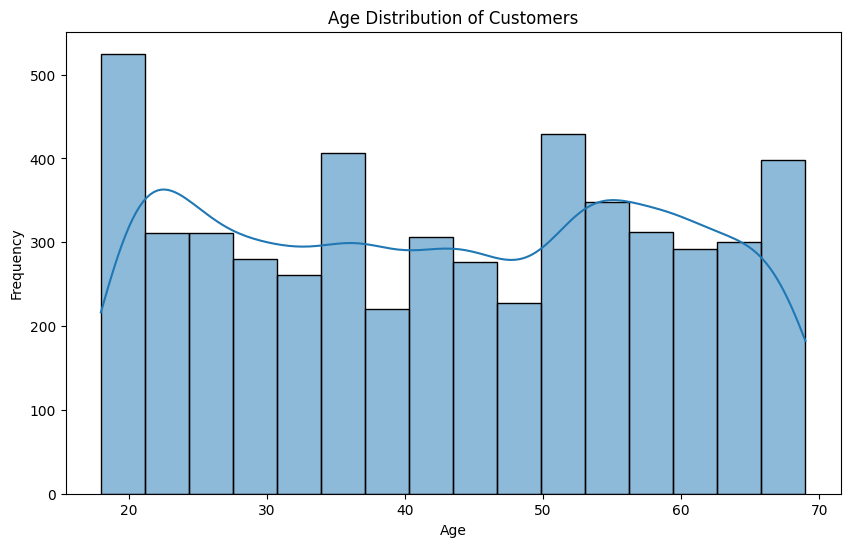

In [22]:
plt.figure(figsize=(10,6))
sns.histplot(df_finall, x = 'Age', kde = True)
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Finding outliers in age and plot it on box plot.

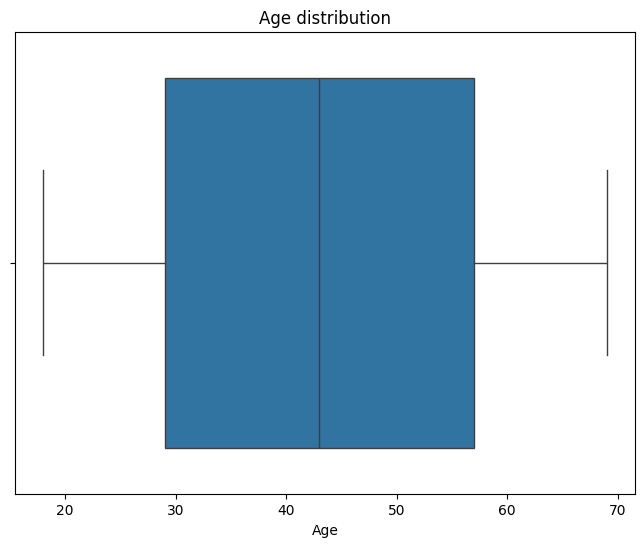

In [23]:
plt.figure(figsize=(8,6))
sns.boxplot(df_finall, x = 'Age')
plt.title('Age distribution')
plt.xlabel('Age')
plt.show()

### Droping unnecessary columns.

In [29]:
drop_columns = ['CustomerID', 'TransactionID', 'InteractionID']
df_finall = df_finall.drop(columns = drop_columns)
print(df_finall.columns)

Index(['Age', 'Gender', 'MaritalStatus', 'IncomeLevel', 'TransactionDate',
       'AmountSpent', 'ProductCategory', 'InteractionDate', 'InteractionType',
       'ResolutionStatus', 'LastLoginDate', 'LoginFrequency', 'ServiceUsage',
       'ChurnStatus'],
      dtype='str')


### Finding correlation between customer churn and its other factor.

In [24]:
# creating variable for storing only numeric value for finding correlation
numeric_df = df_finall.select_dtypes(include = ['number','float', 'int'])

In [26]:
cor_matrix = numeric_df.corr() # finding correlation of numeric column in dataframe.
cor_matrix

,CustomerID,Age,TransactionID,AmountSpent,InteractionID,LoginFrequency,ChurnStatus
CustomerID,1.000000,0.043812,-0.003565,-0.045615,-0.028977,0.015226,-0.049294
Age,0.043812,1.000000,0.000505,0.008364,-0.020427,-0.008731,0.036734
TransactionID,-0.003565,0.000505,1.000000,-0.008370,-0.001195,-0.021537,-0.007670
AmountSpent,-0.045615,0.008364,-0.008370,1.000000,-0.002762,0.034658,-0.000230
InteractionID,-0.028977,-0.020427,-0.001195,-0.002762,1.000000,-0.012829,0.023130
LoginFrequency,0.015226,-0.008731,-0.021537,0.034658,-0.012829,1.000000,-0.096564
ChurnStatus,-0.049294,0.036734,-0.007670,-0.000230,0.023130,-0.096564,1.000000


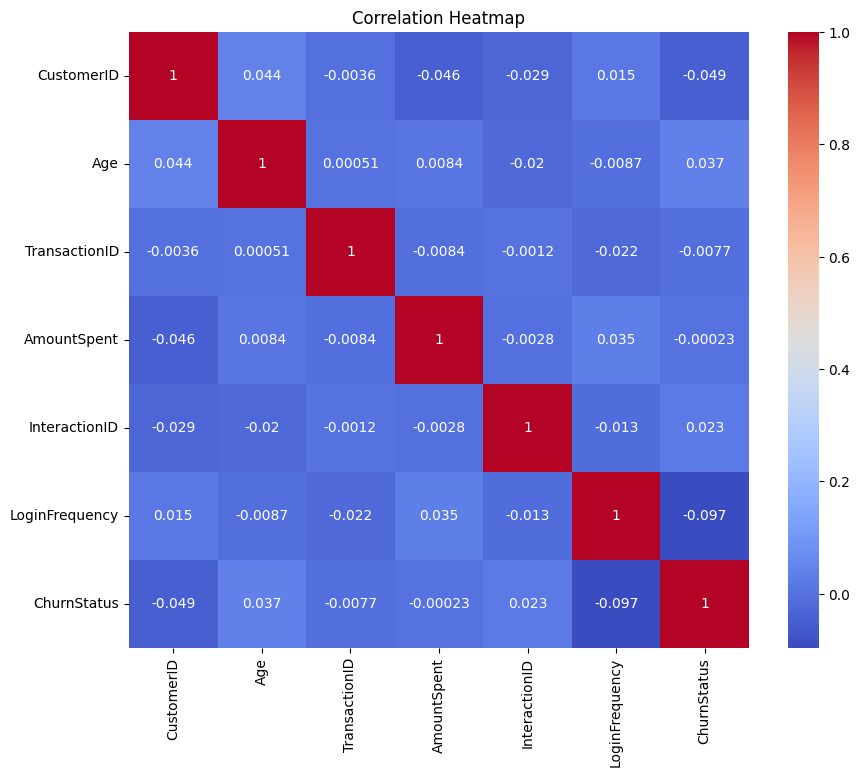

In [27]:
# ploting the correlation on heatmap
plt.figure(figsize=(10,8))
sns.heatmap(cor_matrix, annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()